In [ ]:
import duckdb
# import requests
from pathlib import Path
# import gzip
# import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/Users/nicole/opt/anaconda3/lib/python3.9/site-packages/seaborn/utils.py:10: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.5)
  from scipy import stats


In [2]:
DATA_DIR = Path("./data") 

In [3]:
aggregate_data = False # @param ["False", "True"] {type:"raw"}

In [4]:
DATA_DIR = Path("../data")

DB_PATH = "ecommerce.duckdb"

# Connect to DuckDB (this creates a persistent file on disk)
con = duckdb.connect(DB_PATH)

In [28]:
purchased = con.execute("""
    SELECT user_session, price
    FROM session_summary
    WHERE purchased = TRUE
""").fetchdf()

true_median = np.median(purchased.groupby('user_session').sum())
print(true_median)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

183.25


### CPU MOTHERBOARD MEMORY MEDIAN BOOTSTRAPPING

In [106]:
target_items = con.execute("""
    WITH target_sessions AS (
    SELECT user_session
    FROM session_summary
    WHERE purchased = TRUE 
        AND category_code IS NOT NULL
        AND view_time IS NOT NULL
        AND (
        SPLIT_PART(category_code, '.', 3) = 'memory' OR 
        SPLIT_PART(category_code, '.', 3) = 'motherboard' OR
        SPLIT_PART(category_code, '.', 3) = 'cpu'
        )
    )
    
    SELECT user_session, SUM(price) AS total_price, MIN(view_time) AS time
    FROM session_summary
    WHERE purchased = TRUE AND user_session IN (SELECT user_session FROM target_sessions)
    GROUP BY user_session
    """).fetchdf()

target_items.shape

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(4676, 3)

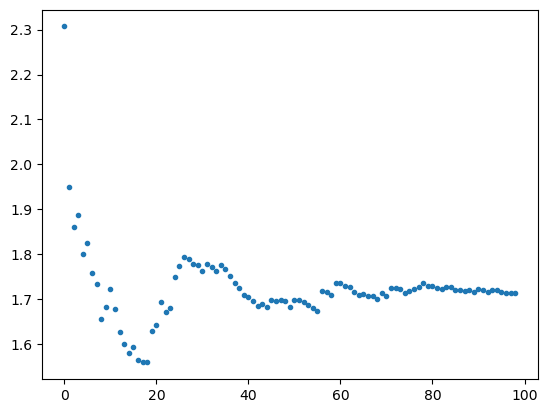

In [82]:
import random

prices = target_items['total_price'].values
boot_meds = []
boot_stds = []

for i in range(0, 1000):
    if (i > 1) and (i % 10 == 0):
        boot_stds.append(np.std(boot_meds))
        
    sample = random.choices(prices, k = 4000)
    
    boot_meds.append(np.median(sample))
    
plt.plot(range(len(boot_stds)), boot_stds, '.')
plt.show()

In [83]:
bootstrap_mean = np.mean(boot_meds)
print(bootstrap_mean)
bootstrap_std = np.std(boot_meds)
print(bootstrap_std)

50.49336
1.7095794103813957


In [103]:
print('ci lower lim:', bootstrap_mean - 1.96 * bootstrap_std / np.sqrt(4000))
print('ci upper lim:', bootstrap_mean + 1.96 * bootstrap_std / np.sqrt(4000))

ci lower lim: 50.44037958517822
ci upper lim: 50.546340414821785


In [88]:
np.median(target_items['total_price'])

50.775

In [102]:
target_items[(target_items['time'] >= '2019-10-01') & (target_items['time'] <= '2019-10-31')]

,user_session,total_price,time
0,d2bf8870-146b-4d3a-8851-b2ed3ae1ada8,145.72,2019-10-02 06:26:54
1,f3cbf376-ffa8-4c4a-a7c5-2e02abfa1edd,603.59,2019-10-14 03:56:24
2,e76c29d7-a479-4982-9014-ea44858c4d90,38.35,2019-10-27 10:44:50
3,84f4609c-1c32-4deb-925f-8d835db02283,239.13,2019-10-16 07:17:51
4,796f21c6-1872-42cf-80c3-7fdc74c51787,143.94,2019-10-18 05:30:07
...,...,...,...
4739,83a5c330-80a1-40c7-9643-ef7bd9e0c677,162.94,2019-10-20 19:32:25
4740,cb935736-ecc8-4bfa-9442-764fbca62a35,401.30,2019-10-10 12:01:21
4755,acff29a0-0830-4633-96e8-3124c2532a3a,484.19,2019-10-07 04:36:27
4756,25b55d39-a38a-48eb-b5c6-30b6f4f4ee85,38.35,2019-10-23 07:49:00


## one and two item cart analysis

In [ ]:
one_item = con.execute("""
    SELECT user_session, SUM(price) AS total_price, COUNT(price) AS item_count
    FROM session_summary
    GROUP BY user_session
    """).fetchdf()
one_item

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [75]:
trans_counts = purchased.groupby('user_session').count()
under_ten = trans_counts[trans_counts < 10]

trans_price = purchased.groupby('user_session').sum()
trans_price['count'] = trans_counts.values

print(np.median(trans_price[trans_price['count'] == 1]['price']))
print(np.median(trans_price[trans_price['count'] == 2]['price']))

174.7
396.13


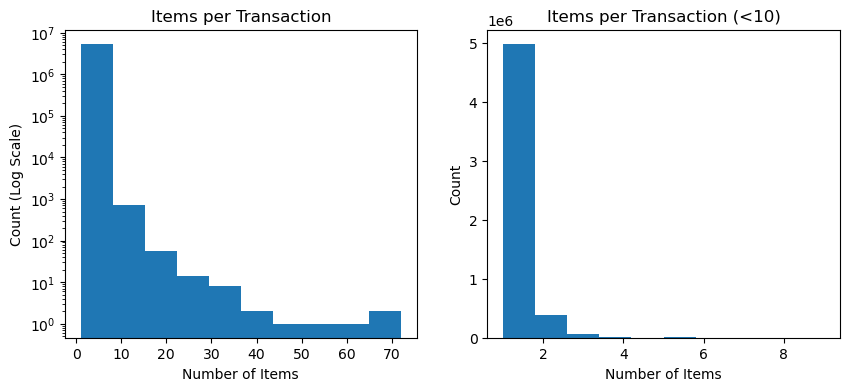

In [65]:
fig, ax = plt.subplots(1, 2, figsize = (10, 4))

ax[0].hist(trans_counts.values)
ax[0].set_yscale('log')
ax[0].set_xlabel('Number of Items')
ax[0].set_ylabel('Count (Log Scale)')
ax[0].set_title('Items per Transaction')

ax[1].hist(under_ten.values)
# ax[1].set_yscale('log')
ax[1].set_xlabel('Number of Items')
ax[1].set_ylabel('Count (Linear Scale)')
ax[1].set_title('Items per Transaction (<10)')
plt.show()

## smartphone/headphone calculations

In [24]:
phone_sessions = con.execute("""
    SELECT user_session
    FROM session_summary
    WHERE SPLIT_PART(category_code, '.', 2) = 'smartphone' AND purchased = TRUE
    GROUP BY user_session
    """).fetchdf()

headphone_sessions = con.execute("""
    SELECT user_session
    FROM session_summary
    WHERE SPLIT_PART(category_code, '.', 3) = 'headphone' AND purchased = TRUE
    GROUP BY user_session
    """).fetchdf()

In [43]:
headphone_prices = con.execute("""SELECT price FROM session_summary 
        WHERE SPLIT_PART(category_code, '.', 3) = 'headphone' AND purchased = TRUE""").fetchdf()

unique_values, counts = np.unique(headphone_prices, return_counts=True) 

most_frequent_value = unique_values[np.argmax(counts)] 

print('mode:', most_frequent_value)

print('mean:', np.mean(df['price']))

print('median:', np.median(df['price']))

mode: 231.64
mean: 396.3504003321987
median: 267.45


In [ ]:
len(phone_sessions) * 0.05 * most_frequent_value

7196904.234